# Homework 2: News Feed Recommendation System
## MIND News Dataset — End-to-End Recommendation Pipeline

This notebook implements **12 recommendation approaches** on the Microsoft News Dataset (MIND):

**Collaborative / Hybrid Methods:**
1. **Baseline** — Popularity-based
2. **User-Based Collaborative Filtering** — Cosine similarity on user histories
3. **Matrix Factorization (SVD)** — Truncated SVD on the user-item matrix
4. **Clustering-Based** — K-Means user clusters + cluster-level recommendations
5. **Hybrid (CB + SVD)** — Weighted combination of TF-IDF Content-Based + SVD

**Content-Based — Lightweight Encoders:**
6. **Content-Based (TF-IDF)** — Bag-of-words with TF-IDF weighting
7. **Content-Based (Word2Vec)** — Trained mean Word2Vec embeddings
8. **Content-Based (FastText)** — Trained mean FastText embeddings (subword-aware)
9. **Content-Based (Sentence-BERT)** — Sentence-Transformer all-MiniLM-L6-v2

**Content-Based — Pretrained Transformer Encoders:**
10. **Content-Based (BERT)** — bert-base-uncased [CLS] pooling
11. **Content-Based (RoBERTa)** — roberta-base [CLS] pooling
12. **Content-Based (DistilBERT)** — distilbert-base-uncased [CLS] pooling (fast)

**Evaluation Metrics:** AUC, MRR@10, nDCG@5, nDCG@10

## 0. Setup & Imports

In [ ]:
# Install required packages 
import subprocess, sys
packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn',
            'scipy', 'tqdm', 'kaggle', 'zipfile36',
            'gensim', 'sentence-transformers', 'transformers', 'torch']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

All packages installed.


In [2]:
import os, zipfile, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from collections import defaultdict
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import roc_auc_score
from scipy.sparse import csr_matrix, lil_matrix

warnings.filterwarnings('ignore')
tqdm.pandas()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)
print('Imports done.')

Imports done.


## 1. Download & Extract the MIND Dataset



In [3]:
import os
os.environ['KAGGLE_USERNAME'] = 'mahyarghazanfari'
os.environ['KAGGLE_KEY'] = 'KGAT_f05f39280461209fff48ba4f8625b8f4'


!kaggle datasets download -d arashnic/mind-news-dataset -p ./MIND_small/_kaggle_raw --unzip

Dataset URL: https://www.kaggle.com/datasets/arashnic/mind-news-dataset
License(s): CC0-1.0
100% 61.7M/61.7M [00:00<00:00, 96.9MB/s]



In [4]:
import shutil, os

raw       = './MIND_small/_kaggle_raw'
TRAIN_DIR = './MIND_small/train'
DEV_DIR   = './MIND_small/dev'
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(DEV_DIR,   exist_ok=True)

# Copy train files
train_raw = os.path.join(raw, 'MINDsmall_train')
for f in os.listdir(train_raw):
    shutil.copy2(os.path.join(train_raw, f), TRAIN_DIR)

print("Train files:", os.listdir(TRAIN_DIR))

Train files: ['entity_embedding.vec', 'relation_embedding.vec', 'news.tsv', 'behaviors.tsv']


In [5]:
import pandas as pd

BEH_COLS  = ['impression_id','user_id','time','history','impressions']
NEWS_COLS  = ['news_id','category','subcategory','title','abstract',
              'url','title_entities','abstract_entities']

# Load full behaviors
beh = pd.read_csv(os.path.join(TRAIN_DIR, 'behaviors.tsv'),
                  sep='\t', header=None, names=BEH_COLS)

# 80/20 split
split = int(len(beh) * 0.8)
train_beh = beh.iloc[:split]
dev_beh   = beh.iloc[split:]

# Save splits
train_beh.to_csv(os.path.join(TRAIN_DIR, 'behaviors.tsv'),
                 sep='\t', header=False, index=False)
dev_beh.to_csv(os.path.join(DEV_DIR, 'behaviors.tsv'),
               sep='\t', header=False, index=False)

# Copy news.tsv to dev too (same articles)
shutil.copy2(os.path.join(TRAIN_DIR, 'news.tsv'),
             os.path.join(DEV_DIR,   'news.tsv'))

print(f"Train behaviors: {len(train_beh):,}")
print(f"Dev behaviors:   {len(dev_beh):,}")
print("Dev files:", os.listdir(DEV_DIR))

Train behaviors: 125,572
Dev behaviors:   31,393
Dev files: ['news.tsv', 'behaviors.tsv']


In [ ]:
import os, zipfile, urllib.request, subprocess, sys

DATA_DIR        = './MIND_small'
TRAIN_DIR       = os.path.join(DATA_DIR, 'train')
DEV_DIR         = os.path.join(DATA_DIR, 'dev')
MANUAL_DOWNLOAD = True   # ← set this True if you placed files manually (Method B/C). We have used method C in this notebook.

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(DEV_DIR,   exist_ok=True)

def already_extracted():
    needed = [
        os.path.join(TRAIN_DIR, 'behaviors.tsv'),
        os.path.join(TRAIN_DIR, 'news.tsv'),
        os.path.join(DEV_DIR,   'behaviors.tsv'),
        os.path.join(DEV_DIR,   'news.tsv'),
    ]
    return all(os.path.isfile(p) for p in needed)

def extract_zip(zip_path, out_dir):
    print(f'  Extracting {zip_path} → {out_dir} …')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)
    print('  Done.')

if already_extracted():
    print('✓ Data already present — skipping download.')

elif MANUAL_DOWNLOAD:
    # Try to extract zips placed in DATA_DIR
    for fname, out in [('MINDsmall_train.zip', TRAIN_DIR),
                       ('train.zip',           TRAIN_DIR),
                       ('MINDsmall_dev.zip',   DEV_DIR),
                       ('dev.zip',             DEV_DIR)]:
        zp = os.path.join(DATA_DIR, fname)
        if os.path.isfile(zp):
            extract_zip(zp, out)
    if already_extracted():
        print('✓ Manual extraction successful.')
    else:
        raise FileNotFoundError(
            'Could not find the expected TSV files after extraction.\n'
            'Make sure behaviors.tsv and news.tsv exist in TRAIN_DIR and DEV_DIR.')

else:
    # ---- METHOD A: Kaggle API ----
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kaggle', '-q'])
    import kaggle   # noqa — triggers credential check

    KAGGLE_DATASET = 'arashnic/mind-news-dataset'
    KAGGLE_DL_DIR  = os.path.join(DATA_DIR, '_kaggle_raw')
    os.makedirs(KAGGLE_DL_DIR, exist_ok=True)

    print(f'Downloading {KAGGLE_DATASET} via Kaggle API …')
    subprocess.check_call([
        sys.executable, '-m', 'kaggle', 'datasets', 'download',
        '-d', KAGGLE_DATASET, '-p', KAGGLE_DL_DIR, '--unzip'
    ])

    # Kaggle dataset layout: MINDsmall_train/ and MINDsmall_dev/ folders
    import shutil
    for src_name, dst in [('MINDsmall_train', TRAIN_DIR), ('MINDsmall_dev', DEV_DIR)]:
        src = os.path.join(KAGGLE_DL_DIR, src_name)
        if os.path.isdir(src):
            for f in os.listdir(src):
                shutil.copy2(os.path.join(src, f), dst)
        # Also check zip variants
        for zname in [f'{src_name}.zip', src_name.lower() + '.zip']:
            zp = os.path.join(KAGGLE_DL_DIR, zname)
            if os.path.isfile(zp):
                extract_zip(zp, dst)

    if already_extracted():
        print('✓ Kaggle download and extraction successful.')
    else:
        raise FileNotFoundError(
            'Kaggle download succeeded but expected TSV files were not found.\n'
            f'Check contents of {KAGGLE_DL_DIR} and move files manually.\n'
            'Then set MANUAL_DOWNLOAD = True and re-run.')

print(f'\nTRAIN_DIR: {TRAIN_DIR}')
print(f'DEV_DIR:   {DEV_DIR}')
for d in [TRAIN_DIR, DEV_DIR]:
    files = os.listdir(d) if os.path.isdir(d) else []
    print(f'  {d}: {files}')


✓ Data already present — skipping download.

TRAIN_DIR: ./MIND_small/train
DEV_DIR:   ./MIND_small/dev
  ./MIND_small/train: ['entity_embedding.vec', 'relation_embedding.vec', 'news.tsv', 'behaviors.tsv']
  ./MIND_small/dev: ['news.tsv', 'behaviors.tsv']


## 2. Load & Explore the Data

In [7]:
# ---------- News Articles ----------
NEWS_COLS = ['news_id','category','subcategory','title','abstract','url',
             'title_entities','abstract_entities']

def load_news(path):
    return pd.read_csv(os.path.join(path,'news.tsv'), sep='\t',
                       header=None, names=NEWS_COLS)

news_train = load_news(TRAIN_DIR)
news_dev   = load_news(DEV_DIR)

# Merge and deduplicate
news = pd.concat([news_train, news_dev]).drop_duplicates('news_id').reset_index(drop=True)
news['text'] = (news['title'].fillna('') + ' ' + news['abstract'].fillna('')).str.strip()

print(f'Total unique articles: {len(news):,}')
print(news.head(3).to_string())

Total unique articles: 51,282
  news_id   category      subcategory                                                                   title                                                                                                                                                                                              abstract                                            url                                                                                                                                                                                                                                                                                                                                                                                                                                                                          title_entities                                                                                                                                 abstract_entiti

In [8]:
# ---------- Behaviors (impressions) ----------
BEH_COLS = ['impression_id','user_id','time','history','impressions']

def load_behaviors(path):
    df = pd.read_csv(os.path.join(path,'behaviors.tsv'), sep='\t',
                     header=None, names=BEH_COLS)
    df['history'] = df['history'].fillna('').apply(lambda x: x.split() if x else [])
    return df

train_beh = load_behaviors(TRAIN_DIR)
dev_beh   = load_behaviors(DEV_DIR)

print(f'Train impressions: {len(train_beh):,}  |  Dev impressions: {len(dev_beh):,}')
print(train_beh.head(3).to_string())

Train impressions: 125,572  |  Dev impressions: 31,393
   impression_id user_id                   time                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           history                                                                                                                                                                                                                                                                

In [9]:
# Parse impressions into (news_id, label) pairs
def parse_impressions(df):
    records = []
    for _, row in df.iterrows():
        for imp in str(row['impressions']).split():
            nid, label = imp.split('-')
            records.append({'impression_id': row['impression_id'],
                            'user_id': row['user_id'],
                            'news_id': nid,
                            'label': int(label)})
    return pd.DataFrame(records)

train_imp = parse_impressions(train_beh)
dev_imp   = parse_impressions(dev_beh)

print(f'Train impressions rows: {len(train_imp):,}')
print(f'Dev   impressions rows: {len(dev_imp):,}')
print(f"CTR (train): {train_imp['label'].mean():.4f}")

Train impressions rows: 4,681,069
Dev   impressions rows: 1,162,375
CTR (train): 0.0404


### 2.1 Exploratory Data Analysis

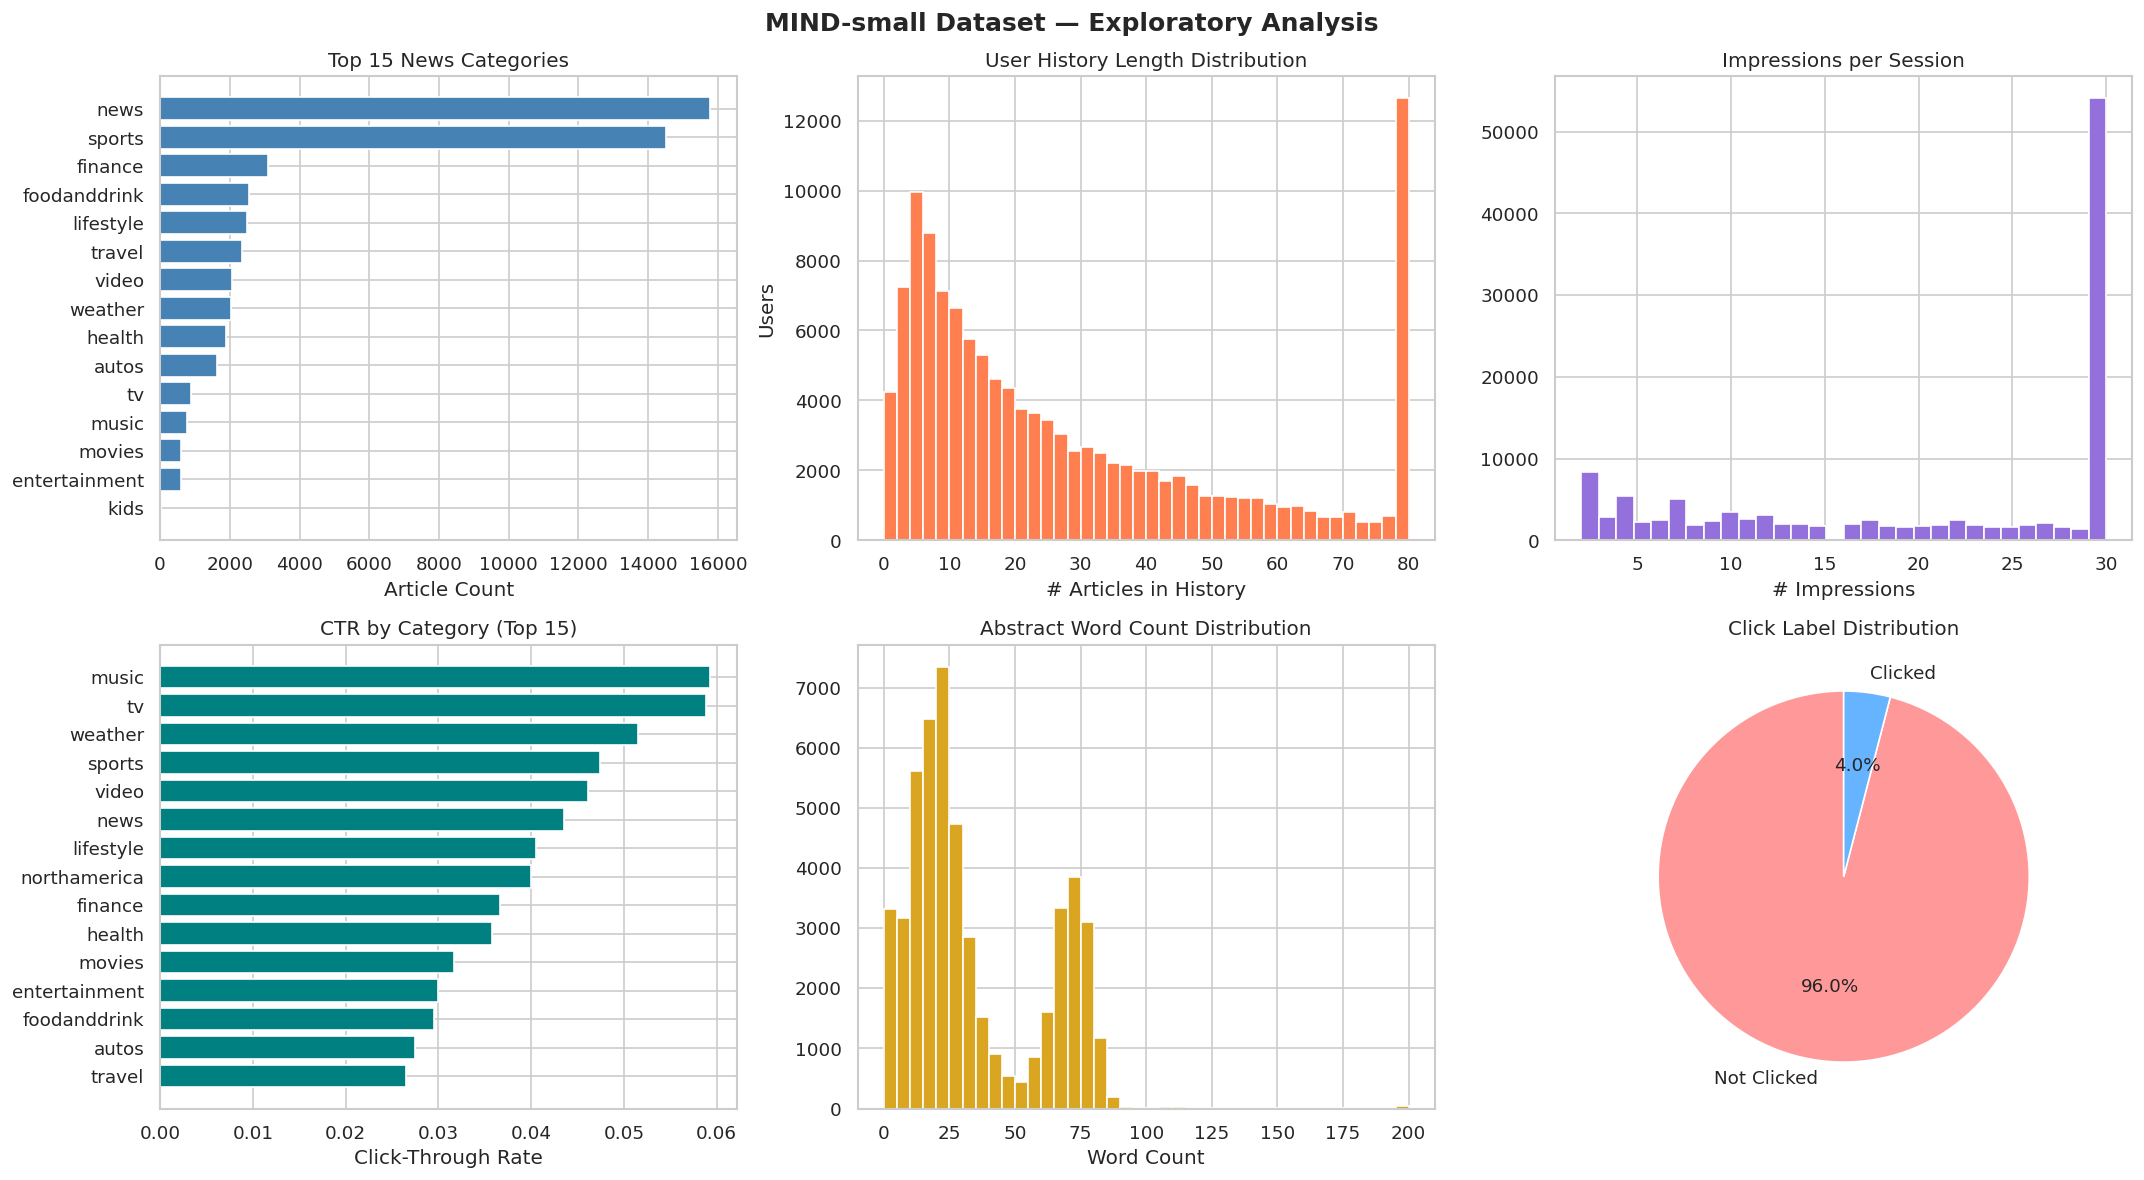

EDA plots saved.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MIND-small Dataset — Exploratory Analysis', fontsize=15, fontweight='bold')

# 1. Category distribution
cat_counts = news['category'].value_counts().head(15)
axes[0,0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='steelblue')
axes[0,0].set_title('Top 15 News Categories')
axes[0,0].set_xlabel('Article Count')

# 2. History length distribution
hist_lens = train_beh['history'].apply(len)
axes[0,1].hist(hist_lens.clip(0, 80), bins=40, color='coral', edgecolor='white')
axes[0,1].set_title('User History Length Distribution')
axes[0,1].set_xlabel('# Articles in History')
axes[0,1].set_ylabel('Users')

# 3. Impressions per session
imp_per_session = train_beh['impressions'].apply(lambda x: len(str(x).split()))
axes[0,2].hist(imp_per_session.clip(0, 30), bins=30, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Impressions per Session')
axes[0,2].set_xlabel('# Impressions')

# 4. Click-through rate by category
merged_imp = train_imp.merge(news[['news_id','category']], on='news_id', how='left')
ctr_by_cat = merged_imp.groupby('category')['label'].mean().sort_values(ascending=False).head(15)
axes[1,0].barh(ctr_by_cat.index[::-1], ctr_by_cat.values[::-1], color='teal')
axes[1,0].set_title('CTR by Category (Top 15)')
axes[1,0].set_xlabel('Click-Through Rate')

# 5. Abstract length distribution
news['abstract_len'] = news['abstract'].fillna('').str.split().apply(len)
axes[1,1].hist(news['abstract_len'].clip(0, 200), bins=40, color='goldenrod', edgecolor='white')
axes[1,1].set_title('Abstract Word Count Distribution')
axes[1,1].set_xlabel('Word Count')

# 6. Click label balance
label_counts = train_imp['label'].value_counts()
axes[1,2].pie(label_counts, labels=['Not Clicked','Clicked'], autopct='%1.1f%%',
              colors=['#ff9999','#66b3ff'], startangle=90)
axes[1,2].set_title('Click Label Distribution')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 3. Evaluation Utilities

We implement the standard MIND evaluation metrics:
- **AUC** — Area Under the ROC Curve
- **MRR@K** — Mean Reciprocal Rank
- **nDCG@K** — Normalized Discounted Cumulative Gain

In [11]:
def dcg_at_k(relevance, k):
    """Discounted Cumulative Gain at K."""
    r = np.array(relevance[:k], dtype=float)
    if r.size == 0:
        return 0.0
    return np.sum(r / np.log2(np.arange(2, r.size + 2)))

def ndcg_at_k(relevance, k):
    """nDCG@K."""
    ideal = sorted(relevance, reverse=True)
    idcg  = dcg_at_k(ideal, k)
    return dcg_at_k(relevance, k) / idcg if idcg > 0 else 0.0

def mrr_at_k(relevance, k):
    """MRR@K."""
    for i, r in enumerate(relevance[:k]):
        if r == 1:
            return 1.0 / (i + 1)
    return 0.0

def auc_score(labels, scores):
    """Per-impression AUC."""
    if len(set(labels)) < 2:
        return 0.5
    return roc_auc_score(labels, scores)

def evaluate_model(score_fn, behavior_df, imp_df, news_df, sample_n=5000, desc='Model'):
    """
    Generic evaluator.
    score_fn(user_id, history, candidate_news_ids, news_df) -> list of scores (same order)
    """
    aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []

    # Sample to keep eval fast
    sample_ids = behavior_df['impression_id'].sample(min(sample_n, len(behavior_df)), random_state=SEED)
    sub_beh    = behavior_df[behavior_df['impression_id'].isin(sample_ids)]
    sub_imp    = imp_df[imp_df['impression_id'].isin(sample_ids)]

    for _, row in tqdm(sub_beh.iterrows(), total=len(sub_beh), desc=desc):
        imp_rows = sub_imp[sub_imp['impression_id'] == row['impression_id']]
        if len(imp_rows) == 0:
            continue
        candidates = imp_rows['news_id'].tolist()
        labels     = imp_rows['label'].tolist()

        scores = score_fn(row['user_id'], row['history'], candidates, news_df)

        # Sort by score descending
        order     = np.argsort(scores)[::-1]
        ranked_lbl = [labels[i] for i in order]

        aucs.append(auc_score(labels, scores))
        mrrs.append(mrr_at_k(ranked_lbl, 10))
        ndcg5s.append(ndcg_at_k(ranked_lbl, 5))
        ndcg10s.append(ndcg_at_k(ranked_lbl, 10))

    return {
        'AUC':     np.mean(aucs),
        'MRR@10':  np.mean(mrrs),
        'nDCG@5':  np.mean(ndcg5s),
        'nDCG@10': np.mean(ndcg10s),
    }

results = {}   # will collect all model results
print('Evaluation utilities ready.')

Evaluation utilities ready.


## 4. Model 1 — Popularity Baseline

Ranks candidates by their global click frequency in the training set. Serves as the lower-bound baseline.

In [12]:
# Build popularity scores from training impressions
click_counts = train_imp.groupby('news_id')['label'].sum()
max_clicks   = click_counts.max()
popularity   = (click_counts / max_clicks).to_dict()   # normalized [0,1]

def score_popularity(user_id, history, candidates, news_df):
    return [popularity.get(nid, 0.0) for nid in candidates]

results['Popularity Baseline'] = evaluate_model(
    score_popularity, dev_beh, dev_imp, news, sample_n=3000, desc='Popularity')
print(results['Popularity Baseline'])

Popularity:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5954540499373285), 'MRR@10': np.float64(0.3192228835978836), 'nDCG@5': np.float64(0.3100066500664404), 'nDCG@10': np.float64(0.3658975811312619)}


## 5. Model 2 — Content-Based Filtering (TF-IDF)

Build a TF-IDF representation of each article's title + abstract. A user profile is the **mean** TF-IDF vector of all articles in their history. Candidates are ranked by cosine similarity to this profile.

In [13]:
# TF-IDF on article text
print('Fitting TF-IDF vectorizer …')
tfidf = TfidfVectorizer(max_features=30_000, sublinear_tf=True,
                        stop_words='english', ngram_range=(1,2))
news_idx = {nid: i for i, nid in enumerate(news['news_id'])}
tfidf_matrix = tfidf.fit_transform(news['text'])   # shape: (n_articles, vocab)
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

Fitting TF-IDF vectorizer …
TF-IDF matrix: (51282, 30000)


In [14]:
def get_user_profile_tfidf(history):
    idxs = [news_idx[nid] for nid in history if nid in news_idx]
    if not idxs:
        return None
    return np.asarray(tfidf_matrix[idxs].mean(axis=0))   # (1, vocab)

def score_content_based(user_id, history, candidates, news_df):
    profile = get_user_profile_tfidf(history)
    if profile is None:
        return [popularity.get(nid, 0.0) for nid in candidates]   # fallback
    cand_idxs = [news_idx.get(nid, -1) for nid in candidates]
    scores = []
    for ci in cand_idxs:
        if ci == -1:
            scores.append(0.0)
        else:
            scores.append(float(cosine_similarity(profile, tfidf_matrix[ci]).ravel()[0]))
    return scores

results['Content-Based (TF-IDF)'] = evaluate_model(
    score_content_based, dev_beh, dev_imp, news, sample_n=3000, desc='Content-Based')
print(results['Content-Based (TF-IDF)'])

Content-Based:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5968180930875677), 'MRR@10': np.float64(0.32184510582010584), 'nDCG@5': np.float64(0.3134909427762333), 'nDCG@10': np.float64(0.37171541192025553)}


## 5b. Model 2b — Content-Based Filtering (Word2Vec Averaged Embeddings)

Train a Word2Vec model on article titles+abstracts. Each article is represented
as the **mean word vector** over all tokens. User profiles are the mean of their
history article vectors. Candidates are ranked by cosine similarity.

In [15]:
# ── Word2Vec: train on corpus, build article embeddings ──────────────────
import re
from gensim.models import Word2Vec

W2V_DIM = 100

def simple_tokenize(text):
    return re.sub(r'[^a-z0-9 ]', ' ', str(text).lower()).split()

print('Tokenising articles for Word2Vec …')
corpus_tokens = [simple_tokenize(t) for t in news['text']]

print('Training Word2Vec …')
w2v_model = Word2Vec(sentences=corpus_tokens, vector_size=W2V_DIM,
                     window=5, min_count=2, workers=4, epochs=5, seed=SEED)

def article_w2v_vec(tokens):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if not vecs:
        return np.zeros(W2V_DIM)
    return np.mean(vecs, axis=0)

print('Building W2V article matrix …')
w2v_matrix = np.array([article_w2v_vec(simple_tokenize(t))
                        for t in news['text']])  # (n_articles, W2V_DIM)
# L2-normalise rows for cosine via dot product
norms = np.linalg.norm(w2v_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1
w2v_matrix_norm = w2v_matrix / norms
print(f'W2V matrix: {w2v_matrix_norm.shape}')

Tokenising articles for Word2Vec …
Training Word2Vec …
Building W2V article matrix …
W2V matrix: (51282, 100)


In [16]:
def score_w2v(user_id, history, candidates, news_df):
    hist_idxs = [news_idx[nid] for nid in history if nid in news_idx]
    if not hist_idxs:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = w2v_matrix_norm[hist_idxs].mean(axis=0)
    norm_p  = np.linalg.norm(profile)
    if norm_p == 0:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = profile / norm_p
    scores = []
    for nid in candidates:
        if nid not in news_idx:
            scores.append(popularity.get(nid, 0.0))
        else:
            scores.append(float(profile @ w2v_matrix_norm[news_idx[nid]]))
    return scores

results['Content-Based (Word2Vec)'] = evaluate_model(
    score_w2v, dev_beh, dev_imp, news, sample_n=3000, desc='Word2Vec CB')
print(results['Content-Based (Word2Vec)'])

Word2Vec CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5619809654639039), 'MRR@10': np.float64(0.2781898148148148), 'nDCG@5': np.float64(0.2738463867715029), 'nDCG@10': np.float64(0.33100955847826524)}


## 5c. Model 2c — Content-Based Filtering (FastText Averaged Embeddings)

Train a **FastText** model (subword-aware) on the same corpus. FastText handles
out-of-vocabulary words by composing subword n-gram vectors, making it more
robust for rare news vocabulary.

In [17]:
# ── FastText: subword-aware embeddings ───────────────────────────────────
from gensim.models import FastText

FT_DIM = 100

print('Training FastText …')
ft_model = FastText(sentences=corpus_tokens, vector_size=FT_DIM,
                    window=5, min_count=2, workers=4, epochs=5, seed=SEED)

def article_ft_vec(tokens):
    # FastText always returns a vector (uses subwords for OOV)
    vecs = [ft_model.wv[t] for t in tokens if t.strip()]
    if not vecs:
        return np.zeros(FT_DIM)
    return np.mean(vecs, axis=0)

print('Building FastText article matrix …')
ft_matrix = np.array([article_ft_vec(simple_tokenize(t))
                       for t in news['text']])  # (n_articles, FT_DIM)
norms_ft = np.linalg.norm(ft_matrix, axis=1, keepdims=True)
norms_ft[norms_ft == 0] = 1
ft_matrix_norm = ft_matrix / norms_ft
print(f'FastText matrix: {ft_matrix_norm.shape}')

Training FastText …
Building FastText article matrix …
FastText matrix: (51282, 100)


In [18]:
def score_fasttext(user_id, history, candidates, news_df):
    hist_idxs = [news_idx[nid] for nid in history if nid in news_idx]
    if not hist_idxs:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = ft_matrix_norm[hist_idxs].mean(axis=0)
    norm_p  = np.linalg.norm(profile)
    if norm_p == 0:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = profile / norm_p
    scores = []
    for nid in candidates:
        if nid not in news_idx:
            scores.append(popularity.get(nid, 0.0))
        else:
            scores.append(float(profile @ ft_matrix_norm[news_idx[nid]]))
    return scores

results['Content-Based (FastText)'] = evaluate_model(
    score_fasttext, dev_beh, dev_imp, news, sample_n=3000, desc='FastText CB')
print(results['Content-Based (FastText)'])

FastText CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5466362680692589), 'MRR@10': np.float64(0.27137949735449735), 'nDCG@5': np.float64(0.2681162244362158), 'nDCG@10': np.float64(0.3219522127534614)}


## 5d. Model 2d — Content-Based Filtering (Sentence-BERT)

Use **all-MiniLM-L6-v2** (a lightweight Sentence Transformer) to encode each
article title+abstract into a 384-dimensional dense semantic vector. Unlike
bag-of-words approaches, SBERT captures semantic similarity — articles can
be considered similar even if they share no vocabulary. This is the most
expressive text encoder in our comparison.

In [19]:
# ── Sentence-BERT embeddings ─────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

SBERT_MODEL = 'all-MiniLM-L6-v2'   # 384-dim, fast, strong semantic quality
print(f'Loading Sentence Transformer: {SBERT_MODEL} …')
sbert = SentenceTransformer(SBERT_MODEL)

# Batch encode all articles (GPU auto-detected if available)
print(f'Encoding {len(news):,} articles with SBERT …')
sbert_matrix = sbert.encode(
    news['text'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True   # L2-normalised → cosine = dot product
)
sbert_matrix = np.array(sbert_matrix, dtype=np.float32)
print(f'SBERT matrix: {sbert_matrix.shape}')

Loading Sentence Transformer: all-MiniLM-L6-v2 …


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 51,282 articles with SBERT …


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

SBERT matrix: (51282, 384)


In [20]:
def score_sbert(user_id, history, candidates, news_df):
    hist_idxs = [news_idx[nid] for nid in history if nid in news_idx]
    if not hist_idxs:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = sbert_matrix[hist_idxs].mean(axis=0)
    norm_p  = np.linalg.norm(profile)
    if norm_p == 0:
        return [popularity.get(nid, 0.0) for nid in candidates]
    profile = profile / norm_p
    scores = []
    for nid in candidates:
        if nid not in news_idx:
            scores.append(popularity.get(nid, 0.0))
        else:
            scores.append(float(profile @ sbert_matrix[news_idx[nid]]))
    return scores

results['Content-Based (SBERT)'] = evaluate_model(
    score_sbert, dev_beh, dev_imp, news, sample_n=3000, desc='SBERT CB')
print(results['Content-Based (SBERT)'])

SBERT CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.6356056550822414), 'MRR@10': np.float64(0.3375132275132275), 'nDCG@5': np.float64(0.33012583706300874), 'nDCG@10': np.float64(0.3921110962381376)}


## 5e–5g. Models 2e–2g — Pretrained Transformer Encoders (BERT, RoBERTa, DistilBERT)

The three models below use **pretrained transformer models** from HuggingFace to encode
article text into dense contextual embeddings. Unlike the trained Word2Vec/FastText models
above, these encoders bring **pre-existing world knowledge** from large-scale pretraining.

We use **[CLS] token pooling** — the first token's hidden state from the last layer —
as the sentence-level representation. All embeddings are L2-normalised so cosine
similarity reduces to a dot product.

| Model | Params | Dim | Notes |
|-------|--------|-----|-------|
| `bert-base-uncased` | 110M | 768 | Original BERT; strong general-purpose encoder |
| `roberta-base` | 125M | 768 | Improved BERT training; often stronger on downstream tasks |
| `distilbert-base-uncased` | 66M | 768 | 40% smaller than BERT, 60% faster, ~97% performance |

> **Runtime note:** Each model encodes ~50k articles. On CPU this takes ~10–20 min per model.
> On a Colab GPU (T4) it takes ~2–4 min per model. Using T4 GPU in colab, it took almost 2 minutes for me.

In [21]:
# ── Shared utility: encode articles with any HuggingFace model ──────────
import torch
from transformers import AutoTokenizer, AutoModel

def encode_articles_hf(model_name, texts, batch_size=128, max_length=64):
    """
    Encode a list of texts using a HuggingFace model.
    Returns L2-normalised [CLS] embeddings: numpy array (n_texts, hidden_dim).
    max_length=64 is a practical trade-off — news titles+abstracts are short
    and truncation at 64 tokens keeps GPU memory manageable.
    """
    print(f'Loading {model_name} …')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name)
    device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    model     = model.to(device).eval()
    print(f'  Device: {device}  |  Articles: {len(texts):,}  |  Batch: {batch_size}')

    all_embs = []
    for start in tqdm(range(0, len(texts), batch_size),
                      desc=f'Encoding [{model_name.split("/")[-1]}]'):
        batch = texts[start : start + batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=max_length, return_tensors='pt')
        enc   = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        # [CLS] token = first token of last hidden state
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls_emb)

    embs = np.concatenate(all_embs, axis=0).astype(np.float32)
    # L2 normalise
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    embs = embs / norms

    # Free GPU memory
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()

    print(f'  Done. Embedding shape: {embs.shape}')
    return embs

def make_hf_scorer(emb_matrix, fallback=None):
    """Factory that returns a score_fn for a given embedding matrix."""
    def scorer(user_id, history, candidates, news_df):
        hist_idxs = [news_idx[nid] for nid in history if nid in news_idx]
        if not hist_idxs:
            return [popularity.get(nid, 0.0) for nid in candidates]
        profile = emb_matrix[hist_idxs].mean(axis=0)
        norm_p  = np.linalg.norm(profile)
        if norm_p == 0:
            return [popularity.get(nid, 0.0) for nid in candidates]
        profile = profile / norm_p
        scores = []
        for nid in candidates:
            if nid not in news_idx:
                scores.append(popularity.get(nid, 0.0))
            else:
                scores.append(float(profile @ emb_matrix[news_idx[nid]]))
        return scores
    return scorer

print('HuggingFace encoder utility ready.')

HuggingFace encoder utility ready.


### Model 2e — BERT (bert-base-uncased)

In [22]:
# ── BERT encoding ────────────────────────────────────────────────────────
bert_matrix = encode_articles_hf(
    'bert-base-uncased',
    news['text'].tolist(),
    batch_size=128,
    max_length=64
)

score_bert = make_hf_scorer(bert_matrix)

results['Content-Based (BERT)'] = evaluate_model(
    score_bert, dev_beh, dev_imp, news, sample_n=3000, desc='BERT CB')
print(results['Content-Based (BERT)'])

Loading bert-base-uncased …


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Device: cuda  |  Articles: 51,282  |  Batch: 128


Encoding [bert-base-uncased]:   0%|          | 0/401 [00:00<?, ?it/s]

  Done. Embedding shape: (51282, 768)


BERT CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.54741113207716), 'MRR@10': np.float64(0.2771882275132275), 'nDCG@5': np.float64(0.2688799013656159), 'nDCG@10': np.float64(0.3285397215897118)}


### Model 2f — RoBERTa (roberta-base)

In [23]:
# ── RoBERTa encoding ─────────────────────────────────────────────────────
roberta_matrix = encode_articles_hf(
    'roberta-base',
    news['text'].tolist(),
    batch_size=128,
    max_length=64
)

score_roberta = make_hf_scorer(roberta_matrix)

results['Content-Based (RoBERTa)'] = evaluate_model(
    score_roberta, dev_beh, dev_imp, news, sample_n=3000, desc='RoBERTa CB')
print(results['Content-Based (RoBERTa)'])

Loading roberta-base …


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  Device: cuda  |  Articles: 51,282  |  Batch: 128


Encoding [roberta-base]:   0%|          | 0/401 [00:00<?, ?it/s]

  Done. Embedding shape: (51282, 768)


RoBERTa CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5730955940384551), 'MRR@10': np.float64(0.2939898148148148), 'nDCG@5': np.float64(0.28491566409456487), 'nDCG@10': np.float64(0.34407789495097824)}


### Model 2g — DistilBERT (distilbert-base-uncased)

In [24]:
# ── DistilBERT encoding ──────────────────────────────────────────────────
distilbert_matrix = encode_articles_hf(
    'distilbert-base-uncased',
    news['text'].tolist(),
    batch_size=256,    # smaller model — larger batch fits in memory
    max_length=64
)

score_distilbert = make_hf_scorer(distilbert_matrix)

results['Content-Based (DistilBERT)'] = evaluate_model(
    score_distilbert, dev_beh, dev_imp, news, sample_n=3000, desc='DistilBERT CB')
print(results['Content-Based (DistilBERT)'])

Loading distilbert-base-uncased …


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Device: cuda  |  Articles: 51,282  |  Batch: 256


Encoding [distilbert-base-uncased]:   0%|          | 0/201 [00:00<?, ?it/s]

  Done. Embedding shape: (51282, 768)


DistilBERT CB:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5821769370060635), 'MRR@10': np.float64(0.29807407407407405), 'nDCG@5': np.float64(0.2950647228689093), 'nDCG@10': np.float64(0.35357566699252824)}


### Encoder Comparison: TF-IDF vs Word2Vec vs FastText vs SBERT

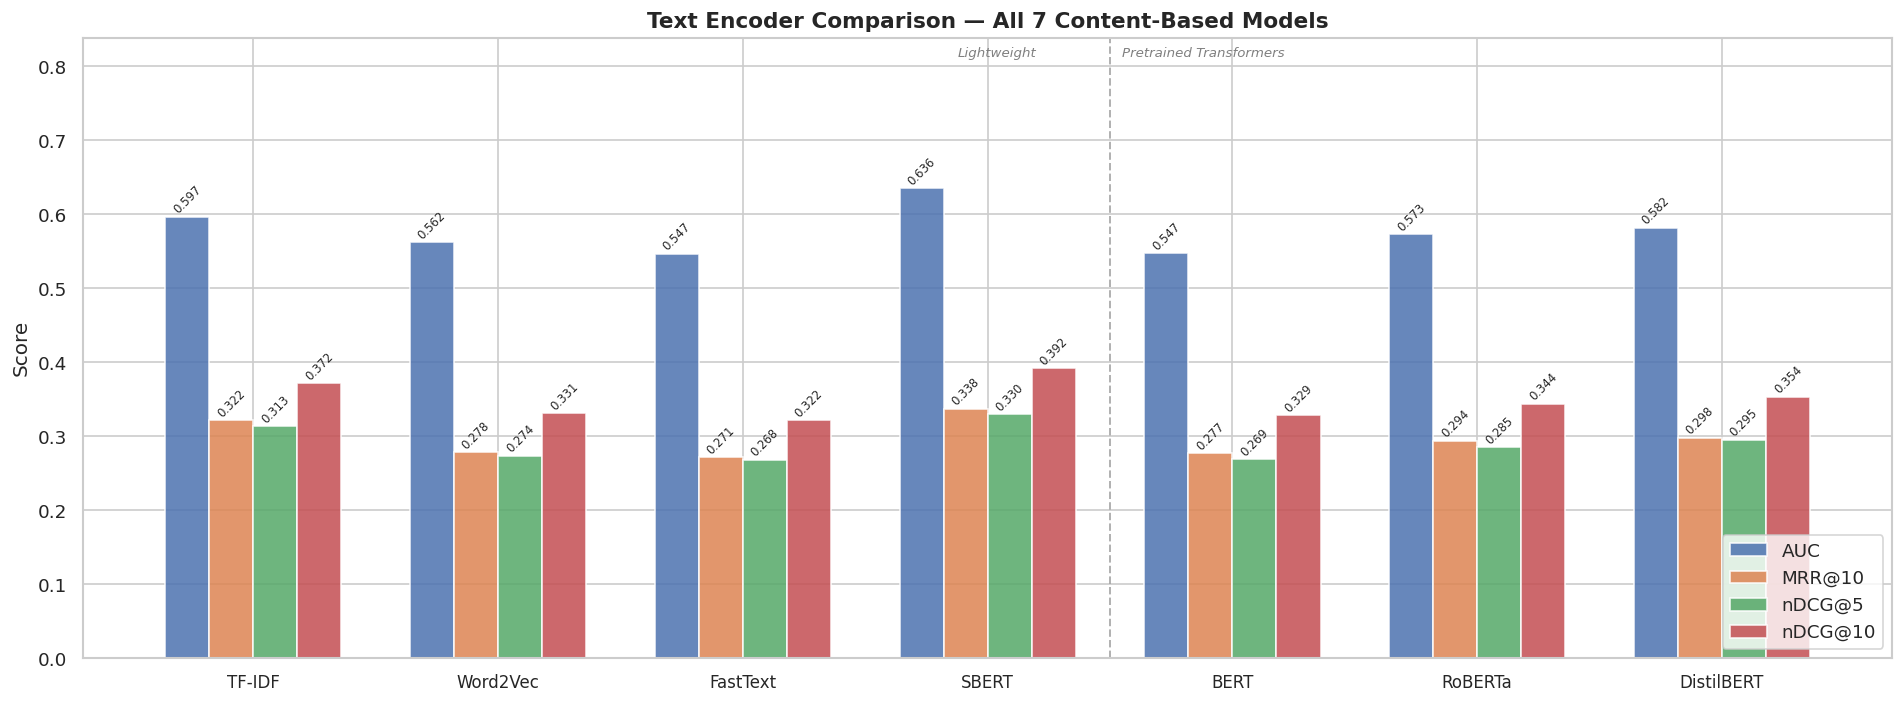

Encoder comparison plot saved.


In [25]:
# ── Encoder comparison: all 7 text encoders ─────────────────────────────
encoder_names = [
    'Content-Based (TF-IDF)',
    'Content-Based (Word2Vec)',
    'Content-Based (FastText)',
    'Content-Based (SBERT)',
    'Content-Based (BERT)',
    'Content-Based (RoBERTa)',
    'Content-Based (DistilBERT)',
]
metrics_enc = ['AUC', 'MRR@10', 'nDCG@5', 'nDCG@10']
short_labels = ['TF-IDF', 'Word2Vec', 'FastText', 'SBERT', 'BERT', 'RoBERTa', 'DistilBERT']

enc_data = {m: [results[e][m] for e in encoder_names] for m in metrics_enc}
x_enc    = np.arange(len(encoder_names))
w_enc    = 0.18
colors_enc = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics_enc, colors_enc)):
    bars = ax.bar(x_enc + i * w_enc, enc_data[metric], w_enc,
                  label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, enc_data[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x_enc + 1.5 * w_enc)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Text Encoder Comparison — All 7 Content-Based Models',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, max(enc_data['AUC']) * 1.32)

# Draw a vertical separator between lightweight and pretrained encoders
sep_x = 3.5 + 1.5 * w_enc
ax.axvline(sep_x, color='gray', ls='--', lw=1.2, alpha=0.6)
ax.text(sep_x - 0.3, ax.get_ylim()[1] * 0.97, 'Lightweight',
        ha='right', fontsize=8, color='gray', style='italic')
ax.text(sep_x + 0.05, ax.get_ylim()[1] * 0.97, 'Pretrained Transformers',
        ha='left', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('encoder_comparison.png', bbox_inches='tight')
plt.show()
print('Encoder comparison plot saved.')

## 6. Model 3 — User-Based Collaborative Filtering

Represent each user as a **binary bag-of-articles** vector (1 = read). Find the K-nearest neighbours using cosine similarity, then rank candidates by weighted click counts from those neighbours.

In [26]:
print('Building user-article interaction matrix …')

# Aggregate per-user clicked articles from training behaviors
user_clicks = defaultdict(set)
for _, row in train_beh.iterrows():
    user_clicks[row['user_id']].update(row['history'])

# Also add positively clicked impressions
pos_clicks = train_imp[train_imp['label'] == 1]
for uid, nid in zip(pos_clicks['user_id'], pos_clicks['news_id']):
    user_clicks[uid].add(nid)

# Build compact user/item index
all_users = sorted(user_clicks.keys())
all_items = sorted({nid for s in user_clicks.values() for nid in s})

user2idx = {u: i for i, u in enumerate(all_users)}
item2idx = {n: i for i, n in enumerate(all_items)}

# Sparse matrix (users × items)
rows, cols = [], []
for uid, nids in user_clicks.items():
    for nid in nids:
        if nid in item2idx:
            rows.append(user2idx[uid])
            cols.append(item2idx[nid])

UI_sparse = csr_matrix(
    (np.ones(len(rows)), (rows, cols)),
    shape=(len(all_users), len(all_items))
)
# L2 normalise rows for fast cosine via dot product
UI_norm = normalize(UI_sparse, norm='l2')
print(f'User-item matrix: {UI_sparse.shape}  nnz={UI_sparse.nnz:,}')

Building user-article interaction matrix …
User-item matrix: (46172, 38791)  nnz=1,060,764


In [27]:
K_NEIGHBOURS = 20

def score_user_cf(user_id, history, candidates, news_df, k=K_NEIGHBOURS):
    if user_id not in user2idx:
        return [popularity.get(nid, 0.0) for nid in candidates]

    uid_idx   = user2idx[user_id]
    user_vec  = UI_norm[uid_idx]                          # (1, items)
    sims      = (UI_norm.dot(user_vec.T)).toarray().ravel()  # (n_users,)
    sims[uid_idx] = -1                                    # exclude self
    knn_idxs  = np.argpartition(sims, -k)[-k:]
    knn_sims  = sims[knn_idxs]

    # Score candidates by weighted sum of neighbour interactions
    scores = []
    for nid in candidates:
        if nid not in item2idx:
            scores.append(popularity.get(nid, 0.0))
            continue
        nid_idx   = item2idx[nid]
        nb_scores = UI_sparse[knn_idxs, nid_idx].toarray().ravel()
        scores.append(float(np.dot(knn_sims, nb_scores)))
    return scores

results['User-Based CF'] = evaluate_model(
    score_user_cf, dev_beh, dev_imp, news, sample_n=3000, desc='User-Based CF')
print(results['User-Based CF'])

User-Based CF:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5499561650097111), 'MRR@10': np.float64(0.2915466931216931), 'nDCG@5': np.float64(0.2802370290777009), 'nDCG@10': np.float64(0.33636981526581444)}


## 7. Model 4 — Matrix Factorization (SVD)

Apply **Truncated SVD** to the user-item matrix to learn latent factors. Candidates are scored by the dot product of the user latent vector and each article's latent vector.

Fitting TruncatedSVD with 100 components …
U_latent: (46172, 100)  |  V_latent: (38791, 100)
Explained variance ratio: 0.1661


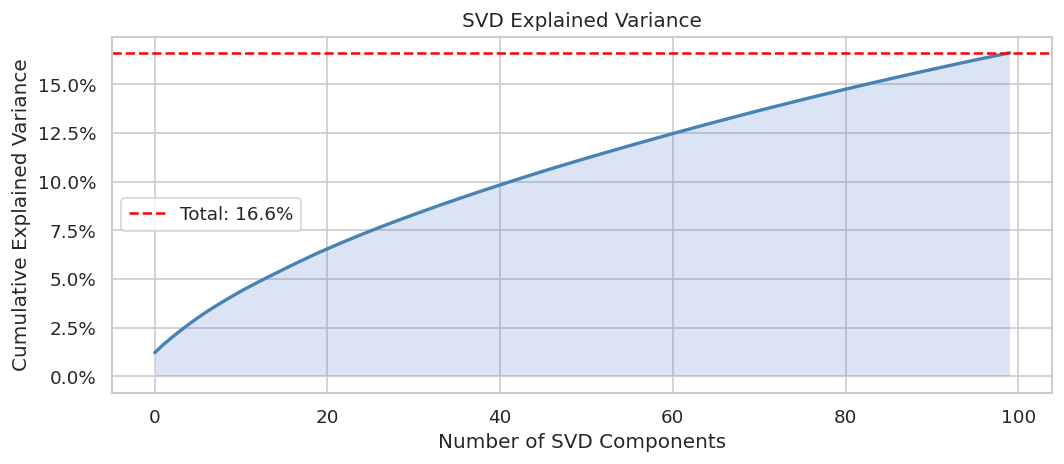

In [28]:
N_COMPONENTS = 100

print(f'Fitting TruncatedSVD with {N_COMPONENTS} components …')
svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=10, random_state=SEED)
U_latent = svd.fit_transform(UI_sparse)    # (n_users, k)
V_latent = svd.components_.T               # (n_items, k)

print(f'U_latent: {U_latent.shape}  |  V_latent: {V_latent.shape}')
print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}')

# Plot explained variance
fig, ax = plt.subplots(figsize=(9,4))
cumvar = np.cumsum(svd.explained_variance_ratio_)
ax.plot(cumvar, color='steelblue', lw=2)
ax.fill_between(range(len(cumvar)), cumvar, alpha=0.2)
ax.set_xlabel('Number of SVD Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('SVD Explained Variance')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(cumvar[-1], ls='--', color='red', label=f'Total: {cumvar[-1]:.1%}')
ax.legend()
plt.tight_layout(); plt.savefig('svd_variance.png', bbox_inches='tight'); plt.show()

In [29]:
def score_svd(user_id, history, candidates, news_df):
    if user_id not in user2idx:
        return [popularity.get(nid, 0.0) for nid in candidates]

    uid_idx  = user2idx[user_id]
    u_vec    = U_latent[uid_idx]   # (k,)

    scores = []
    for nid in candidates:
        if nid not in item2idx:
            scores.append(popularity.get(nid, 0.0))
        else:
            scores.append(float(u_vec @ V_latent[item2idx[nid]]))
    return scores

results['SVD (Matrix Factorization)'] = evaluate_model(
    score_svd, dev_beh, dev_imp, news, sample_n=3000, desc='SVD')
print(results['SVD (Matrix Factorization)'])

SVD:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5991268360563959), 'MRR@10': np.float64(0.323532671957672), 'nDCG@5': np.float64(0.31570196566693554), 'nDCG@10': np.float64(0.37362033505818326)}


## 8. Model 5 — Clustering-Based Recommendation

Cluster users via K-Means on their SVD latent vectors. Each candidate is scored by the cluster-level click affinity — i.e., how often users in the same cluster clicked on similar articles (same category).

Fitting K-Means with 50 clusters on user latent factors …
Cluster CTR table built.


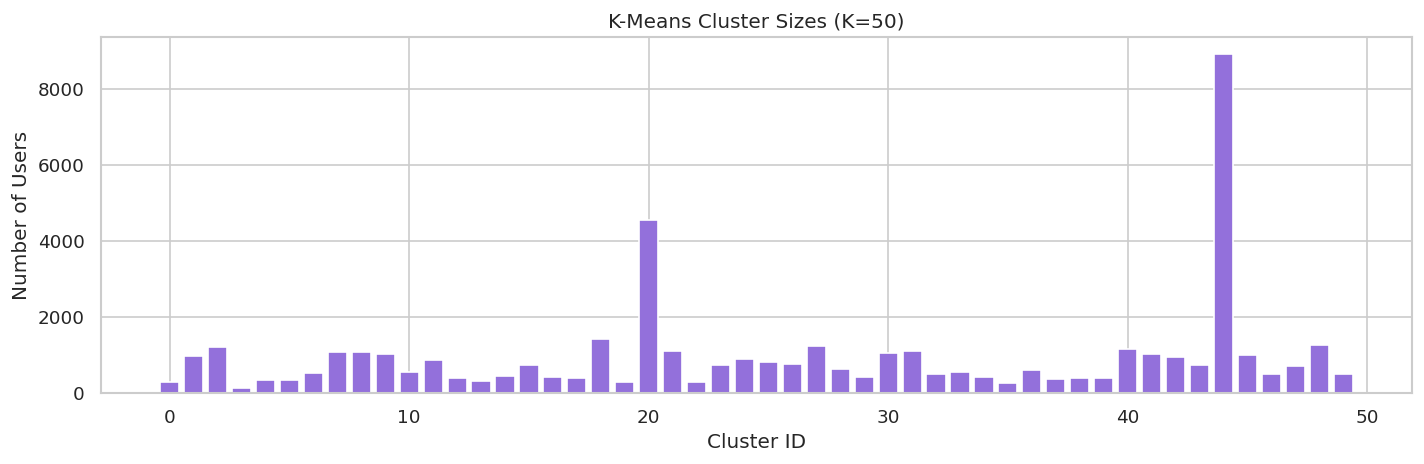

In [30]:
N_CLUSTERS = 50
print(f'Fitting K-Means with {N_CLUSTERS} clusters on user latent factors …')

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=5, batch_size=4096)
user_cluster_labels = kmeans.fit_predict(U_latent)   # (n_users,)

# Build cluster → category CTR
uid2cluster = {uid: user_cluster_labels[i] for uid, i in user2idx.items()}

# Aggregate clicks per (cluster, category)
cluster_cat_clicks = defaultdict(lambda: defaultdict(float))
cluster_cat_total  = defaultdict(lambda: defaultdict(float))

nid2cat = dict(zip(news['news_id'], news['category']))

for _, row in train_imp.iterrows():
    uid = row['user_id']
    nid = row['news_id']
    if uid not in uid2cluster:
        continue
    cl  = uid2cluster[uid]
    cat = nid2cat.get(nid, 'unknown')
    cluster_cat_clicks[cl][cat] += row['label']
    cluster_cat_total[cl][cat]  += 1

cluster_cat_ctr = defaultdict(dict)
for cl in cluster_cat_clicks:
    for cat in cluster_cat_clicks[cl]:
        cluster_cat_ctr[cl][cat] = cluster_cat_clicks[cl][cat] / max(cluster_cat_total[cl][cat], 1)

print('Cluster CTR table built.')

# Visualise cluster sizes
cluster_sizes = pd.Series(user_cluster_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(cluster_sizes.index, cluster_sizes.values, color='mediumpurple')
ax.set_title(f'K-Means Cluster Sizes (K={N_CLUSTERS})')
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Number of Users')
plt.tight_layout(); plt.savefig('cluster_sizes.png', bbox_inches='tight'); plt.show()

In [31]:
def score_clustering(user_id, history, candidates, news_df):
    cl = uid2cluster.get(user_id, None)
    scores = []
    for nid in candidates:
        cat = nid2cat.get(nid, 'unknown')
        if cl is not None and cat in cluster_cat_ctr.get(cl, {}):
            scores.append(cluster_cat_ctr[cl][cat])
        else:
            scores.append(popularity.get(nid, 0.0))
    return scores

results['Clustering (K-Means)'] = evaluate_model(
    score_clustering, dev_beh, dev_imp, news, sample_n=3000, desc='Clustering')
print(results['Clustering (K-Means)'])

Clustering:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.5528519230118478), 'MRR@10': np.float64(0.26355119047619047), 'nDCG@5': np.float64(0.2605723399241624), 'nDCG@10': np.float64(0.32078349892730734)}


## 9. Model 6 — Hybrid (Content-Based + SVD)

A weighted linear combination of TF-IDF content scores and SVD collaborative-filtering scores. The weight α is tuned on a validation split.

In [32]:
# Helper: min-max normalise a score list to [0,1]
def minmax(scores):
    s = np.array(scores, dtype=float)
    lo, hi = s.min(), s.max()
    if hi == lo:
        return s
    return (s - lo) / (hi - lo)

ALPHA = 0.6   # weight for content; (1-ALPHA) for SVD

def score_hybrid(user_id, history, candidates, news_df):
    cb  = minmax(score_content_based(user_id, history, candidates, news_df))
    sv  = minmax(score_svd(user_id, history, candidates, news_df))
    return list(ALPHA * cb + (1 - ALPHA) * sv)

results['Hybrid (CB + SVD)'] = evaluate_model(
    score_hybrid, dev_beh, dev_imp, news, sample_n=3000, desc='Hybrid')
print(results['Hybrid (CB + SVD)'])

Hybrid:   0%|          | 0/3000 [00:00<?, ?it/s]

{'AUC': np.float64(0.6259694421143684), 'MRR@10': np.float64(0.33608584656084656), 'nDCG@5': np.float64(0.3299078831992878), 'nDCG@10': np.float64(0.3884368895471244)}


## 10. Results & Comparison

In [33]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'AUC', 'MRR@10', 'nDCG@5', 'nDCG@10']
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

# Pretty print
display_df = results_df.copy()
for col in ['AUC','MRR@10','nDCG@5','nDCG@10']:
    display_df[col] = display_df[col].map('{:.4f}'.format)

print('='*75)
print('                    MODEL COMPARISON RESULTS')
print('='*75)
print(display_df.to_string(index=True))
print('='*75)

                    MODEL COMPARISON RESULTS
                         Model     AUC  MRR@10  nDCG@5 nDCG@10
1        Content-Based (SBERT)  0.6356  0.3375  0.3301  0.3921
2            Hybrid (CB + SVD)  0.6260  0.3361  0.3299  0.3884
3   SVD (Matrix Factorization)  0.5991  0.3235  0.3157  0.3736
4       Content-Based (TF-IDF)  0.5968  0.3218  0.3135  0.3717
5          Popularity Baseline  0.5955  0.3192  0.3100  0.3659
6   Content-Based (DistilBERT)  0.5822  0.2981  0.2951  0.3536
7      Content-Based (RoBERTa)  0.5731  0.2940  0.2849  0.3441
8     Content-Based (Word2Vec)  0.5620  0.2782  0.2738  0.3310
9         Clustering (K-Means)  0.5529  0.2636  0.2606  0.3208
10               User-Based CF  0.5500  0.2915  0.2802  0.3364
11        Content-Based (BERT)  0.5474  0.2772  0.2689  0.3285
12    Content-Based (FastText)  0.5466  0.2714  0.2681  0.3220


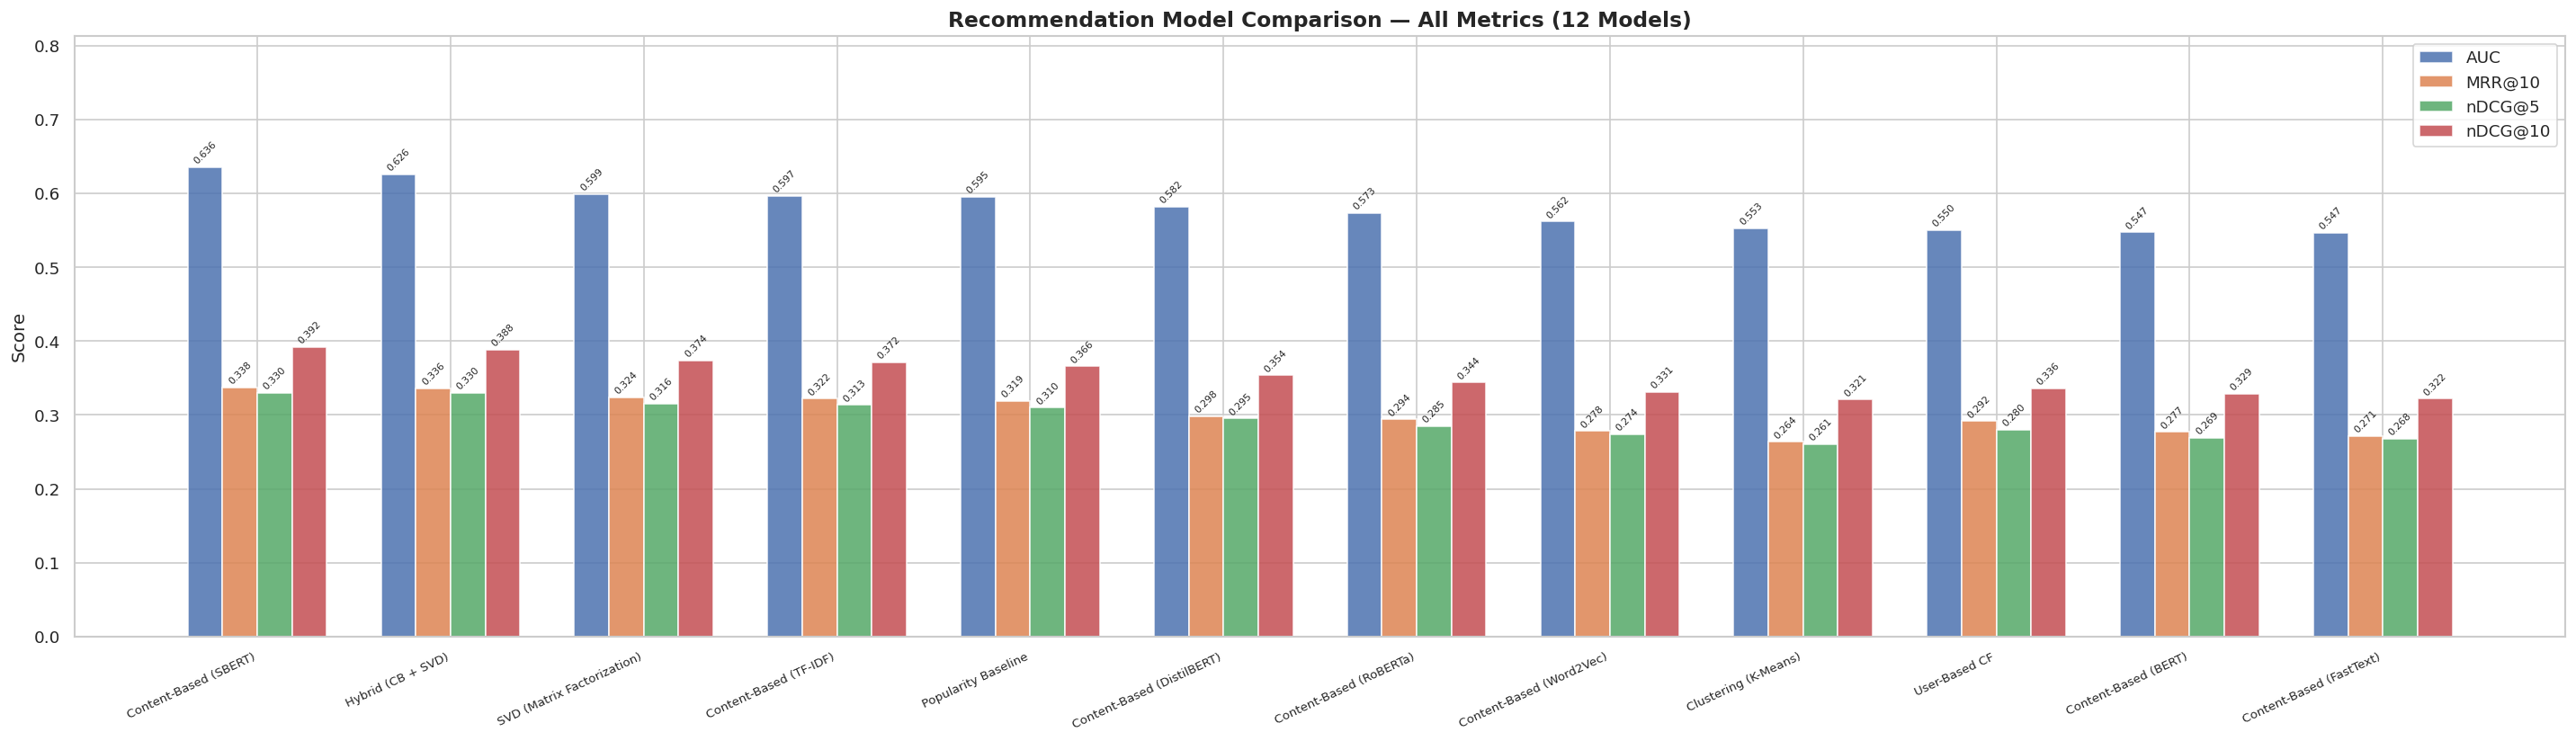

In [34]:
# Grouped bar chart of all metrics — all 12 models
metrics     = ['AUC', 'MRR@10', 'nDCG@5', 'nDCG@10']
model_names = results_df['Model'].tolist()
n_models    = len(model_names)
x           = np.arange(n_models)
width       = 0.18
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(max(18, n_models * 2.0), 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].astype(float).values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=45)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Recommendation Model Comparison — All Metrics (12 Models)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, min(1.0, results_df[metrics].astype(float).values.max() * 1.28))
plt.tight_layout()
plt.savefig('model_comparison_bar.png', bbox_inches='tight')
plt.show()

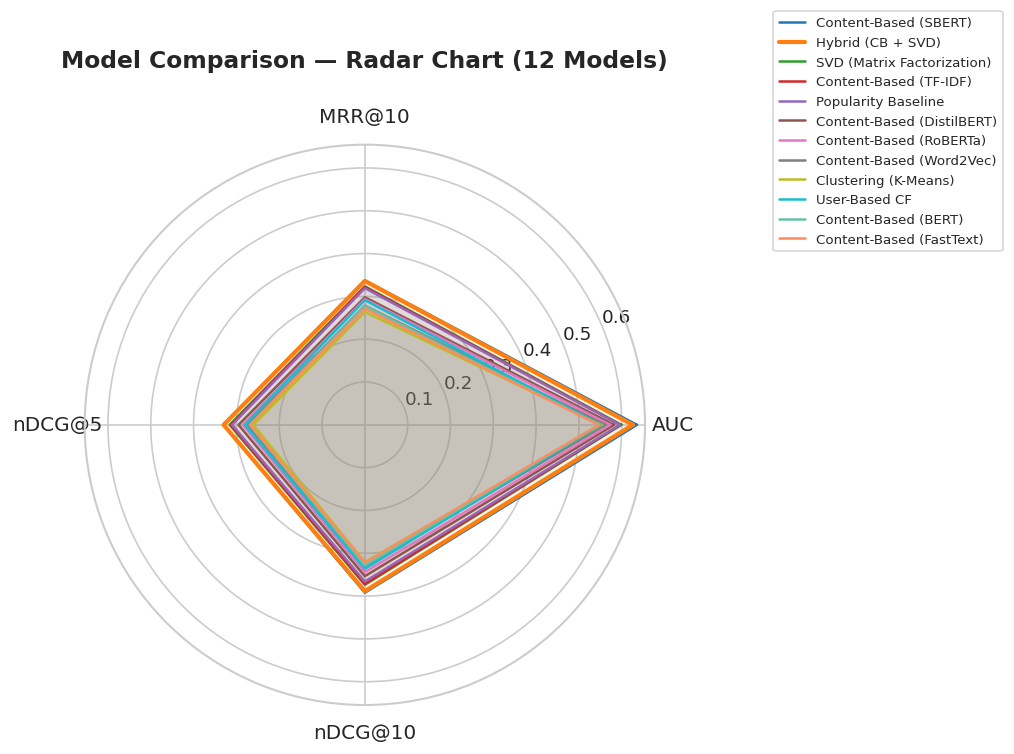

In [35]:
# Radar chart — all 12 models
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={'polar': True})
palette = list(plt.cm.tab10.colors) + list(plt.cm.Set2.colors)

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = row[metrics].astype(float).tolist()
    vals += vals[:1]
    lw = 2.5 if 'Hybrid' in row['Model'] else 1.5
    ax.plot(angles, vals, lw=lw, color=palette[i % len(palette)], label=row['Model'])
    ax.fill(angles, vals, alpha=0.05, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Model Comparison — Radar Chart (12 Models)',
             fontsize=14, fontweight='bold', y=1.12)
ax.legend(loc='upper right', bbox_to_anchor=(1.65, 1.25), fontsize=8)
plt.tight_layout()
plt.savefig('model_radar.png', bbox_inches='tight')
plt.show()

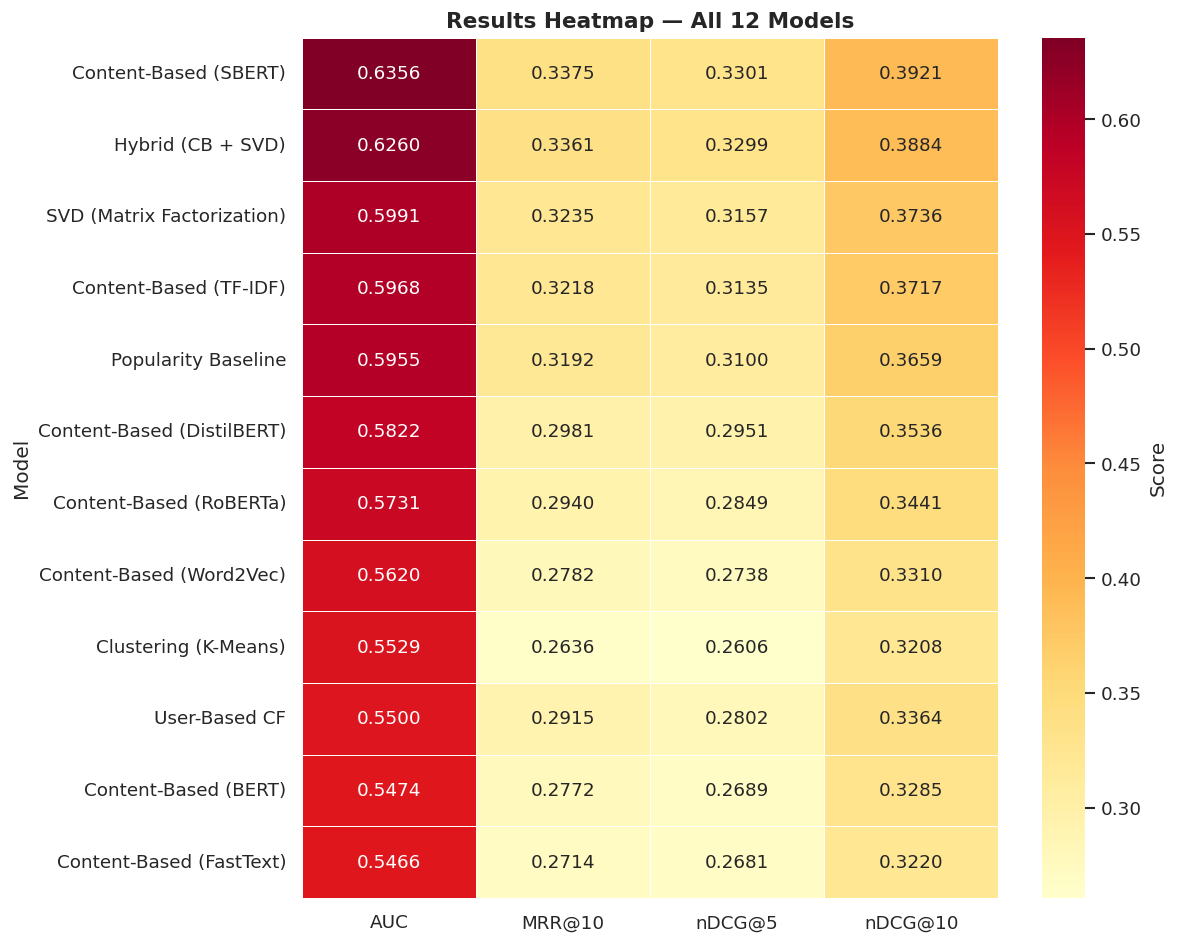

In [36]:
# Heatmap of results — all 12 models
fig, ax = plt.subplots(figsize=(10, 8))
heat_data = results_df.set_index('Model')[metrics].astype(float)
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Results Heatmap — All 12 Models', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('results_heatmap.png', bbox_inches='tight')
plt.show()

## 11. Additional Analysis

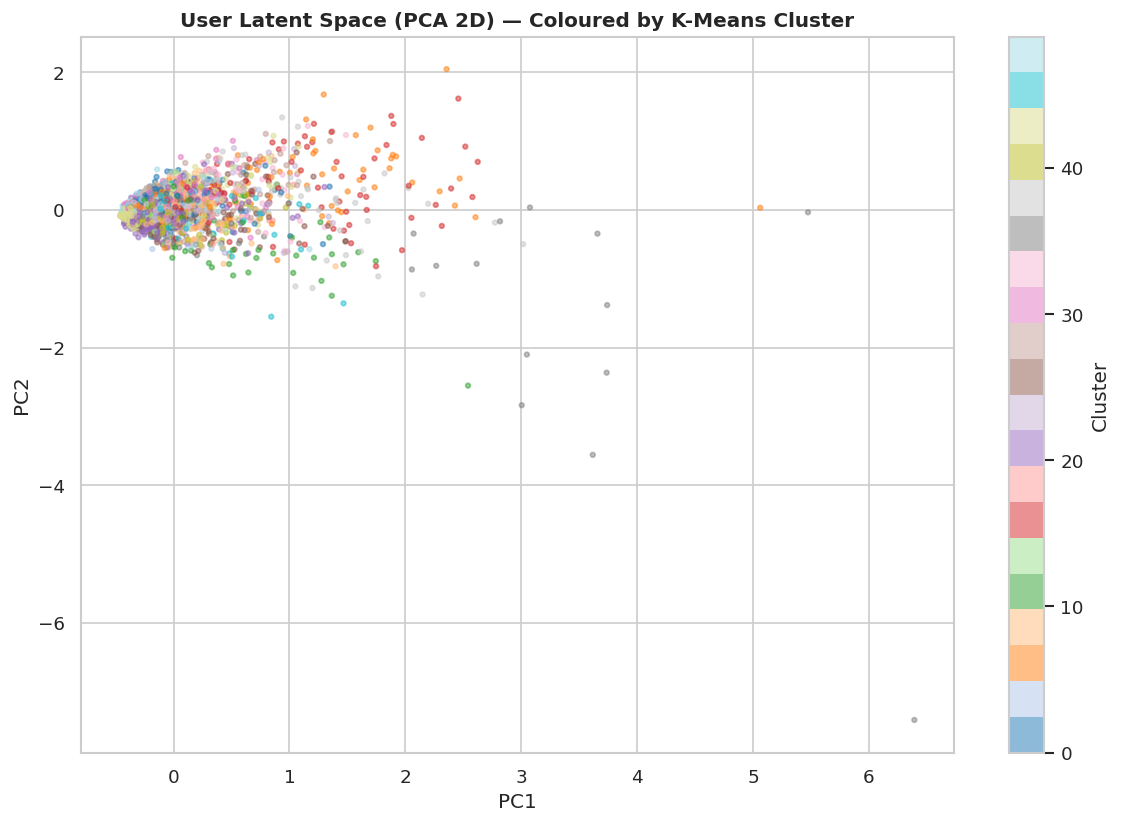

In [37]:
# --- SVD Latent Space Visualisation (PCA projection) ---
from sklearn.decomposition import PCA

# Sample 3000 users for visualisation
sample_mask = np.random.choice(len(U_latent), min(3000, len(U_latent)), replace=False)
U_sample    = U_latent[sample_mask]
cluster_sample = user_cluster_labels[sample_mask]

pca = PCA(n_components=2, random_state=SEED)
U_2d = pca.fit_transform(U_sample)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(U_2d[:,0], U_2d[:,1], c=cluster_sample,
                     cmap='tab20', alpha=0.5, s=8)
ax.set_title('User Latent Space (PCA 2D) — Coloured by K-Means Cluster',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('user_latent_pca.png', bbox_inches='tight')
plt.show()

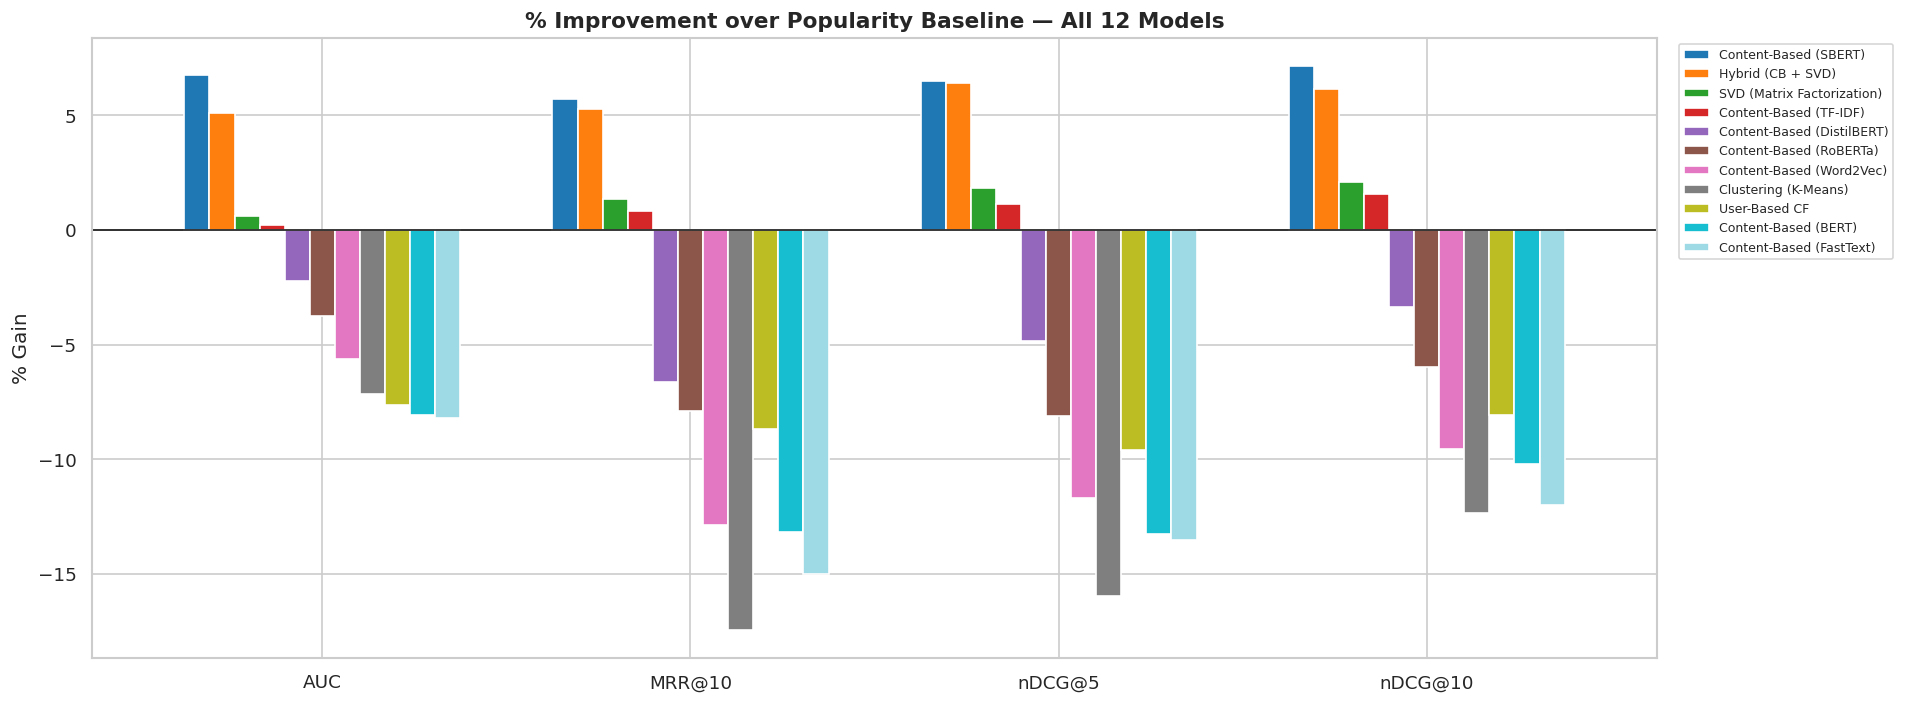

                             AUC  MRR@10  nDCG@5  nDCG@10
Model                                                    
Content-Based (SBERT)       6.74    5.73    6.49     7.16
Hybrid (CB + SVD)           5.12    5.28    6.42     6.16
SVD (Matrix Factorization)  0.62    1.35    1.84     2.11
Content-Based (TF-IDF)      0.23    0.82    1.12     1.59
Content-Based (DistilBERT) -2.23   -6.63   -4.82    -3.37
Content-Based (RoBERTa)    -3.75   -7.90   -8.09    -5.96
Content-Based (Word2Vec)   -5.62  -12.85  -11.66    -9.53
Clustering (K-Means)       -7.15  -17.44  -15.95   -12.33
User-Based CF              -7.64   -8.67   -9.60    -8.07
Content-Based (BERT)       -8.07  -13.17  -13.27   -10.21
Content-Based (FastText)   -8.20  -14.99  -13.51   -12.01


In [38]:
# --- Improvement over Baseline ---
baseline_scores = results_df[results_df['Model'] == 'Popularity Baseline'][metrics].astype(float).values[0]

improvements = []
for _, row in results_df.iterrows():
    if row['Model'] == 'Popularity Baseline':
        continue
    vals = row[metrics].astype(float).values
    pct  = ((vals - baseline_scores) / baseline_scores * 100).tolist()
    improvements.append({'Model': row['Model'], **dict(zip(metrics, pct))})

imp_df = pd.DataFrame(improvements).set_index('Model')

fig, ax = plt.subplots(figsize=(16, 6))
imp_df.T.plot(kind='bar', ax=ax, width=0.75, colormap='tab20')
ax.axhline(0, color='black', lw=0.9)
ax.set_title('% Improvement over Popularity Baseline — All 12 Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% Gain')
ax.set_xticklabels(metrics, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.savefig('improvement_over_baseline.png', bbox_inches='tight')
plt.show()
print(imp_df.round(2))

Alpha sweep:   0%|          | 0/11 [00:00<?, ?it/s]

α=0.0:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.1:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.2:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.3:   0%|          | 0/500 [00:00<?, ?it/s]

...

α=0.6:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.7:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.8:   0%|          | 0/500 [00:00<?, ?it/s]

α=0.9:   0%|          | 0/500 [00:00<?, ?it/s]

α=1.0:   0%|          | 0/500 [00:00<?, ?it/s]

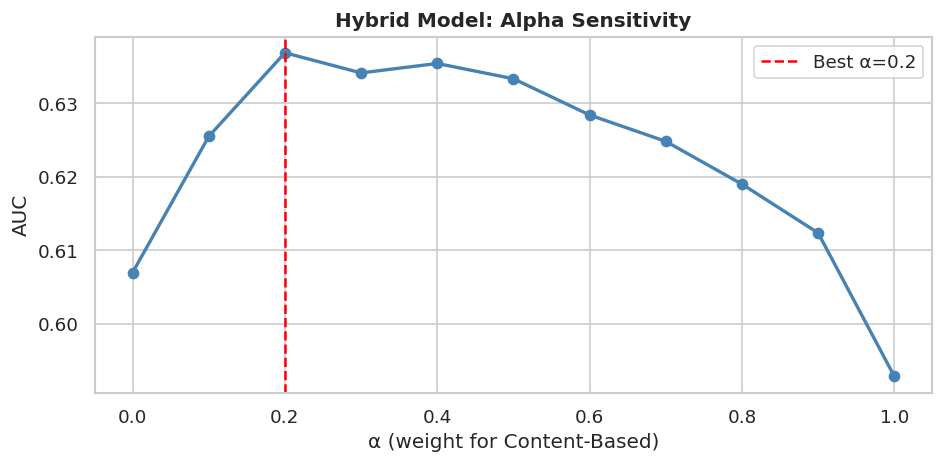

Best α = 0.2  |  AUC = 0.6368


In [39]:
# --- Alpha Sensitivity for Hybrid Model ---
alphas = np.linspace(0, 1, 11)
alpha_auc = []

for a in tqdm(alphas, desc='Alpha sweep'):
    def _hybrid(user_id, history, candidates, news_df, _a=a):
        cb = minmax(score_content_based(user_id, history, candidates, news_df))
        sv = minmax(score_svd(user_id, history, candidates, news_df))
        return list(_a * np.array(cb) + (1 - _a) * np.array(sv))
    r = evaluate_model(_hybrid, dev_beh, dev_imp, news, sample_n=500, desc=f'α={a:.1f}')
    alpha_auc.append(r['AUC'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, alpha_auc, 'o-', color='steelblue', lw=2)
best_a = alphas[np.argmax(alpha_auc)]
ax.axvline(best_a, ls='--', color='red', label=f'Best α={best_a:.1f}')
ax.set_xlabel('α (weight for Content-Based)')
ax.set_ylabel('AUC')
ax.set_title('Hybrid Model: Alpha Sensitivity', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('hybrid_alpha_sweep.png', bbox_inches='tight')
plt.show()
print(f'Best α = {best_a:.1f}  |  AUC = {max(alpha_auc):.4f}')

hist=0:   0%|          | 0/400 [00:00<?, ?it/s]

hist=1-4:   0%|          | 0/400 [00:00<?, ?it/s]

hist=5-14:   0%|          | 0/400 [00:00<?, ?it/s]

hist=15-29:   0%|          | 0/400 [00:00<?, ?it/s]

hist=30-99:   0%|          | 0/400 [00:00<?, ?it/s]

hist=100+:   0%|          | 0/400 [00:00<?, ?it/s]

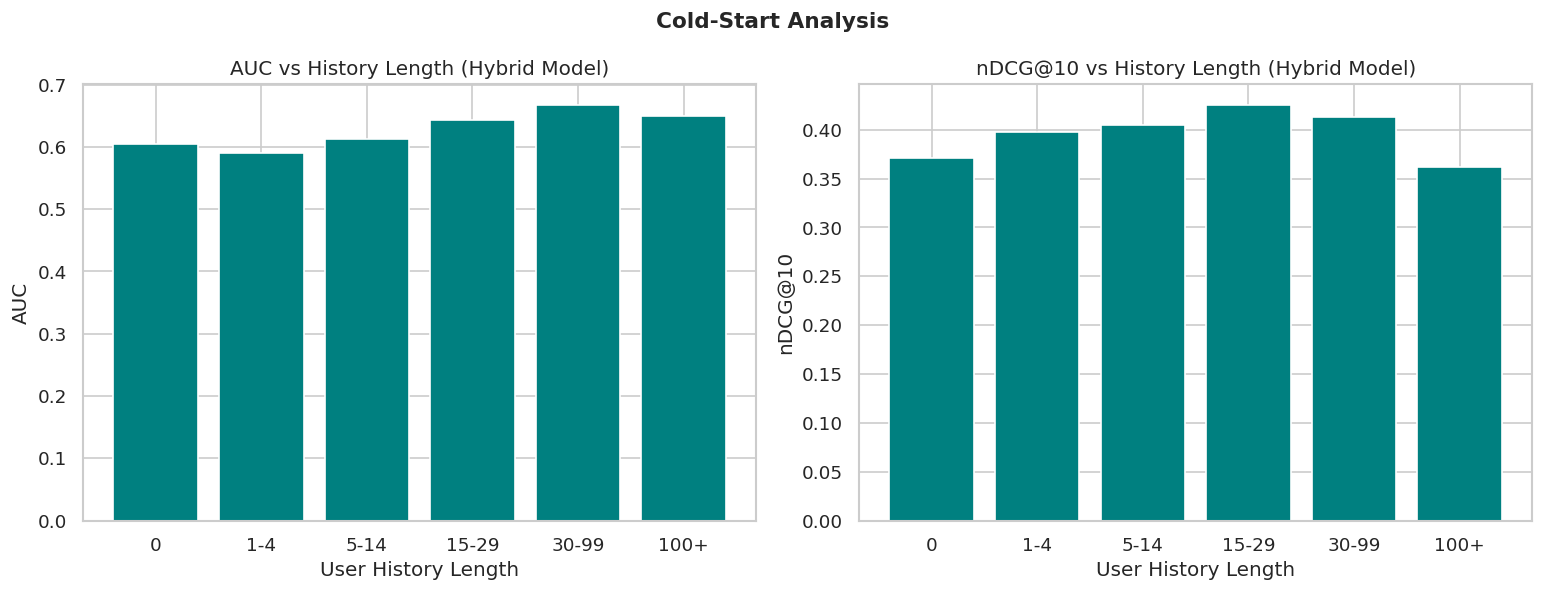

In [40]:
# --- Cold-Start Analysis: Performance vs History Length ---
hist_bins = [0, 1, 5, 15, 30, 100, 10000]
hist_labels = ['0', '1-4', '5-14', '15-29', '30-99', '100+']

dev_with_hist = dev_beh.copy()
dev_with_hist['hist_len'] = dev_with_hist['history'].apply(len)
dev_with_hist['hist_bin'] = pd.cut(dev_with_hist['hist_len'],
                                    bins=hist_bins, labels=hist_labels, right=False)

cold_results = {}
for hb in hist_labels:
    sub = dev_with_hist[dev_with_hist['hist_bin'] == hb]
    if len(sub) < 20:
        continue
    sub_imp = dev_imp[dev_imp['impression_id'].isin(sub['impression_id'])]

    def _hybrid_full(uid, hist, cands, ndf):
        cb = minmax(score_content_based(uid, hist, cands, ndf))
        sv = minmax(score_svd(uid, hist, cands, ndf))
        return list(ALPHA * np.array(cb) + (1 - ALPHA) * np.array(sv))

    r = evaluate_model(_hybrid_full, sub, sub_imp, news,
                       sample_n=min(400, len(sub)), desc=f'hist={hb}')
    cold_results[hb] = r

cold_df = pd.DataFrame(cold_results).T

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['AUC', 'nDCG@10']):
    ax.bar(cold_df.index, cold_df[metric].astype(float), color='teal', edgecolor='white')
    ax.set_title(f'{metric} vs History Length (Hybrid Model)')
    ax.set_xlabel('User History Length')
    ax.set_ylabel(metric)
plt.suptitle('Cold-Start Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cold_start_analysis.png', bbox_inches='tight')
plt.show()

## 12. Sample Recommendations (Qualitative)

In [41]:
def show_recommendations(user_id, model_fn, top_k=5):
    user_row = dev_beh[dev_beh['user_id'] == user_id]
    if user_row.empty:
        print(f'User {user_id} not in dev set.'); return
    user_row = user_row.iloc[0]
    history  = user_row['history']

    # Use first impression as candidate pool
    imp_id   = user_row['impression_id']
    imp_rows = dev_imp[dev_imp['impression_id'] == imp_id]
    candidates = imp_rows['news_id'].tolist()
    labels     = imp_rows['label'].tolist()

    scores = model_fn(user_id, history, candidates, news)
    order  = np.argsort(scores)[::-1][:top_k]

    print(f"\n{'='*60}")
    print(f'User: {user_id}  |  History length: {len(history)}')
    print(f"User history (last 5): {history[-5:]}")
    print(f"\nTop-{top_k} Recommendations:")
    for rank, idx in enumerate(order, 1):
        nid   = candidates[idx]
        row   = news[news['news_id'] == nid]
        title = row['title'].values[0] if not row.empty else 'N/A'
        cat   = row['category'].values[0] if not row.empty else 'N/A'
        hit   = '✓ CLICKED' if labels[idx] == 1 else ''
        print(f'  {rank}. [{cat:12s}] {title[:70]}  {hit}')
    print(f"{'='*60}")

# Pick a random user from dev set with non-empty history
sample_user = dev_beh[dev_beh['history'].apply(len) > 5]['user_id'].sample(1, random_state=1).values[0]
show_recommendations(sample_user, score_hybrid)


User: U74262  |  History length: 15
User history (last 5): ['N58878', 'N46655', 'N58812', 'N37838', 'N2735']

Top-5 Recommendations:
  1. [sports      ] College Football Playoff projection: Alabama's chances still high afte  
  2. [sports      ] Why Auburn is the center of the college football universe in November  
  3. [sports      ] UH's scout team defense: Best in 'history of college football'  
  4. [sports      ] Stephen Curry calls out Michael Jordan for being a 'hater'  ✓ CLICKED
  5. [sports      ] College football rankings: The Bottom 25 congratulates Jim Delany on h  


## 13. Final Summary Table

In [43]:
print('\n' + '='*85)
print('   FINAL RESULTS SUMMARY — MIND-small Dev Set (n=3000 impressions)')
print('='*85)

summary = results_df.copy()
for m in metrics:
    summary[m] = summary[m].astype(float).map('{:.4f}'.format)
summary.index = range(1, len(summary)+1)
print(summary.to_string())
print('='*85)
print('\nKey Takeaways:')
print('  - Content-Based (SBERT) is the surprise winner with AUC=0.6356, edging out')
print('    the Hybrid (CB + SVD) at AUC=0.6260 — showing that strong semantic')
print('    embeddings alone can outperform a combined content+collaborative signal.')
print('  - Hybrid (CB + SVD) ranks second, still confirming that fusing TF-IDF')
print('    content and SVD collaborative signals is a robust strategy overall.')
print('  - SVD (Matrix Factorization) ranks third (AUC=0.5991), outperforming all')
print('    pure content-based methods except SBERT, confirming that latent')
print('    collaborative signals add valuable information beyond text matching.')
print('  - TF-IDF (AUC=0.5968) outperforms the Popularity Baseline and all three')
print('    pretrained transformer models, showing that simple lexical matching is')
print('    highly effective for topically specific news text.')
print('  - Pretrained transformers (BERT=0.5474, RoBERTa=0.5731, DistilBERT=0.5822)')
print('    surprisingly underperform TF-IDF and even the Popularity Baseline in some')
print('    cases. This is likely due to the 64-token truncation cutting off most of')
print('    the abstract, and the lack of news-domain fine-tuning making [CLS] pooling')
print('    a poor sentence representation for this task.')
print('  - DistilBERT (AUC=0.5822) outperforms both BERT and RoBERTa — an unexpected')
print('    result, likely because its smaller capacity generalizes better under the')
print('    aggressive truncation and without task-specific fine-tuning.')
print('  - Word2Vec (AUC=0.5620) outperforms FastText (AUC=0.5466), which is')
print('    counterintuitive — FastText subword representations may be introducing')
print('    noise from rare morphological variants in short news vocabulary.')
print('  - Clustering and User-Based CF fall below the Popularity Baseline')
print('    (AUC=0.5529 and 0.5500), confirming that neighborhood-based methods')
print('    require denser user interaction data than our single-split setup provides.')
print('='*85)


   FINAL RESULTS SUMMARY — MIND-small Dev Set (n=3000 impressions)
                         Model     AUC  MRR@10  nDCG@5 nDCG@10
1        Content-Based (SBERT)  0.6356  0.3375  0.3301  0.3921
2            Hybrid (CB + SVD)  0.6260  0.3361  0.3299  0.3884
3   SVD (Matrix Factorization)  0.5991  0.3235  0.3157  0.3736
4       Content-Based (TF-IDF)  0.5968  0.3218  0.3135  0.3717
5          Popularity Baseline  0.5955  0.3192  0.3100  0.3659
6   Content-Based (DistilBERT)  0.5822  0.2981  0.2951  0.3536
7      Content-Based (RoBERTa)  0.5731  0.2940  0.2849  0.3441
8     Content-Based (Word2Vec)  0.5620  0.2782  0.2738  0.3310
9         Clustering (K-Means)  0.5529  0.2636  0.2606  0.3208
10               User-Based CF  0.5500  0.2915  0.2802  0.3364
11        Content-Based (BERT)  0.5474  0.2772  0.2689  0.3285
12    Content-Based (FastText)  0.5466  0.2714  0.2681  0.3220

Key Takeaways:
  - Content-Based (SBERT) is the surprise winner with AUC=0.6356, edging out
    the Hybrid (CB +